# Lista 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

from Lista3 import data_preprocessing
from Lista3.Logging import setup_logging
from Lista3.Algorithms.Bagging.bagging import BaggingClassifier
from Lista3.Algorithms.Bagging.bagging_analysis import (
    plot_comparison_bars,
    plot_feature_importances,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

logger = setup_logging.setup_logging(logging.INFO)


In [2]:
df = data_preprocessing.load_dataset()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   occupation                   100000 non-null  str    
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  str    
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_units_before_bed     100000 non-null  float64
 13  screen_time

In [3]:
df_encoded = data_preprocessing.df_label_encoding(df)

target_col_reg = 'cognitive_performance_score'
target_col_cat = 'felt_rested'
X_encoded, y_encoded = data_preprocessing.extract_target(df_encoded, target_col_reg)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=13
)

print(f"\nRozmiar zbioru treningowego: {X_train.shape[0]} wierszy x {X_train.shape[1]} kolumn")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} wierszy x {X_test.shape[1]} kolumn")

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print(f"\nPo standaryzacji:")
print(f"X_train: mean = {X_train_scaled.mean(axis=0)[:3]}, std = {X_train_scaled.std(axis=0)[:3]}")


Rozmiar zbioru treningowego: 80000 wierszy x 30 kolumn
Rozmiar zbioru testowego: 20000 wierszy x 30 kolumn

Po standaryzacji:
X_train: mean = [ 7.86926080e-17 -4.13891144e-17 -1.50723878e-16], std = [1. 1. 1.]


## Lasso i Ridge

### Analiza regularyzacji (Lasso vs Ridge)

**Uwaga**: używamy `warm_start=True`, co inicjalizuje każdy model od poprzedniego rozwiązania.
Dzięki temu ścieżki wag są gładkie i reprezentują rzeczywiste zachowanie algorytmu.


In [5]:
# alphas = np.logspace(-2, -1, 8)
# learning_rate = 0.005
# epochs = 3000
# zero_tol = 1e-4
# feature_names = X_encoded.columns.tolist()
#
# stats = compare_lasso_ridge(
#     X_train_scaled,
#     np.asarray(y_train),
#     alphas,
#     learning_rate=learning_rate,
#     epochs=epochs,
#     zero_tol=zero_tol,
#     feature_names=feature_names)
#
# stats

W tabeli `zero_count` oznacza liczbę wag bliskich zera (|w| <= 1e-3). Lasso powinno
zwiększać ten licznik wraz ze wzrostem `alpha`, a Ridge zwykle tylko zmniejsza
wagi bez „wyzerowania”.

### Zestawienie regularyzacji regresji

Por?wnujemy model bazowy (alpha = 0) z Lasso i Ridge dla wielu warto?ci `alpha`.
Dodatkowo mierzymy `train/test` dla MSE i MAE oraz liczb? wag bliskich zera.


In [6]:
# regression_alphas = np.r_[0.0, np.logspace(-4, -1, 8)]
# learning_rate = 0.005
# epochs = 3000
#
# regression_results = regularized_regression_results(
#     X_train_scaled,
#     X_test_scaled,
#     y_train,
#     y_test,
#     alphas=regression_alphas,
#     learning_rate=learning_rate,
#     epochs=epochs,
# )
#
# display(regression_results.sort_values(["penalty", "alpha"]))
#
# plot_comparison_results(regression_results)
# plt.show()

### Regularyzacja drzew decyzyjnych

Badamy wp?yw `min_samples_split`, `min_samples_leaf` i `max_features` na przeuczenie.
Szukamy ustawie?, kt?re poprawiaj? jako?? na zbiorze testowym wzgl?dem zbyt g??bokiego drzewa bazowego.


In [7]:


X_tree, y_tree = data_preprocessing.extract_target(df_encoded, target_col_cat)

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=13, stratify=y_tree
)
#
# tree_baseline = fit_tree_classifier(
#     X_tree_train, y_tree_train,
#     criterion="entropy",
#     random_state=13,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features=None,
# )
# baseline_tree_metrics = evaluate_tree_classifier(
#     tree_baseline, X_tree_train, y_tree_train, X_tree_test, y_tree_test
# )
# pd.Series({k: v for k, v in baseline_tree_metrics.items() if not k.endswith("_pred")})


In [8]:
# tree_sweeps = {}
#
# tree_sweeps["min_samples_split"] = sweep_tree_parameter(
#     X_tree_train,
#     y_tree_train,
#     X_tree_test,
#     y_tree_test,
#     param_name="min_samples_split",
#     param_values=[50, 500, 2000, 5000, 10000],
#     base_params={
#         "criterion": "entropy",
#         "random_state": 13,
#         "max_depth": None,
#         "min_samples_leaf": 1,
#         "max_features": None,
#     },
# )
#
# tree_sweeps["min_samples_leaf"] = sweep_tree_parameter(
#     X_tree_train,
#     y_tree_train,
#     X_tree_test,
#     y_tree_test,
#     param_name="min_samples_leaf",
#     param_values=[50, 500, 1000, 2000, 5000],
#     base_params={
#         "criterion": "entropy",
#         "random_state": 13,
#         "max_depth": None,
#         "min_samples_split": 2,
#         "max_features": None,
#     },
# )
#
# tree_sweeps["max_features"] = sweep_tree_parameter(
#     X_tree_train,
#     y_tree_train,
#     X_tree_test,
#     y_tree_test,
#     param_name="max_features",
#     param_values=[None, "sqrt", "log2", 10, 20],
#     base_params={
#         "criterion": "entropy",
#         "random_state": 13,
#         "max_depth": None,
#         "min_samples_split": 1000,
#         "min_samples_leaf": 100,
#     },
# )


In [9]:
# tree_summaries = {}
#
# for name, df_results in tree_sweeps.items():
#     summary, best_row = summarize_tree_sweep(df_results, metric="test_f1_weighted")
#     tree_summaries[name] = {
#         "summary": summary,
#         "best": best_row,
#     }
#     print(f"\n{name}:")
#     display(summary)
#     print("Najlepsze ustawienie:")
#     display(best_row.to_frame().T)
#     plot_train_test_curves(df_results, metric="f1_weighted", param_label=name)
#
# plt.show()


## Bagging (Bootstrap Aggregating)

Ensemble method, który łączy wiele słabszych modeli (tu: drzew decyzyjnych) trenowanych
na bootstrap samples, aby zmniejszyć wariancję i poprawić generalizację.


### 1. Porównanie: Pojedyncze drzewo vs sklearn Bagging vs Własna impelmentacja Bagging


In [10]:
# Pojedyncze drzewo decyzyjne
single_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=13
)
single_tree.fit(X_tree_train, y_tree_train)

# sklearn RandomForestClassifier
sklearn_rf = RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=13,
    n_jobs=-1
)
sklearn_rf.fit(X_tree_train, y_tree_train)

# Własna implementacja Bagging
custom_bagging = BaggingClassifier(
    n_estimators=20,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='entropy',
    random_state=13,
    bootstrap=True
)
custom_bagging.fit(X_tree_train, y_tree_train)

In [11]:
comparison_data = []
for name, model in [("Single Tree", single_tree), ("sklearn RF", sklearn_rf), ("Custom Bagging", custom_bagging)]:
    y_train_pred = model.predict(X_tree_train)
    y_test_pred = model.predict(X_tree_test)

    comparison_data.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_tree_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_tree_test, y_test_pred),
        'Train F1': f1_score(y_tree_train, y_train_pred, average='weighted', zero_division=0),
        'Test F1': f1_score(y_tree_test, y_test_pred, average='weighted', zero_division=0),
        'Overfitting (gap)': accuracy_score(y_tree_train, y_train_pred) - accuracy_score(y_tree_test, y_test_pred),
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nPorównanie wyników:")
display(comparison_df)



Porównanie wyników:


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Overfitting (gap)
0,Single Tree,0.802625,0.70955,0.801595,0.708036,0.093075
1,sklearn RF,0.833712,0.73595,0.832976,0.734158,0.097762
2,Custom Bagging,0.814475,0.73720,0.812874,0.734106,0.077275


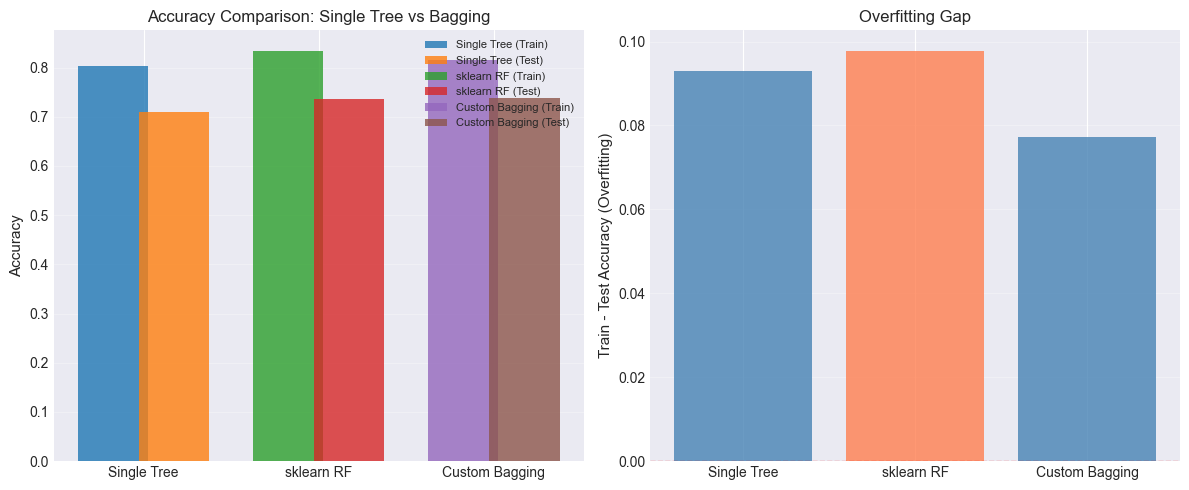

In [12]:
# Wykres porównania
fig = plot_comparison_bars(comparison_df, figsize=(12, 5))
plt.show()


### 2. Wpływ liczby drzew (n_estimators) na wydajność


In [13]:
n_estimators_list = [1, 3, 5, 10, 15, 20, 30, 50]

results_custom = []
for n_est in n_estimators_list:
    model = BaggingClassifier(
        n_estimators=n_est,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        criterion='entropy',
        random_state=13
    )
    model.fit(X_tree_train, y_tree_train)

    y_train_pred = model.predict(X_tree_train)
    y_test_pred = model.predict(X_tree_test)

    results_custom.append({
        'n_estimators': n_est,
        'train_accuracy': accuracy_score(y_tree_train, y_train_pred),
        'test_accuracy': accuracy_score(y_tree_test, y_test_pred),
        'train_f1': f1_score(y_tree_train, y_train_pred, average='weighted', zero_division=0),
        'test_f1': f1_score(y_tree_test, y_test_pred, average='weighted', zero_division=0),
    })

results_df = pd.DataFrame(results_custom)
print("Wpływ liczby drzew na wydajność (Custom Bagging):")
display(results_df)


Wpływ liczby drzew na wydajność (Custom Bagging):


,n_estimators,train_accuracy,test_accuracy,train_f1,test_f1
0,1,0.778487,0.69445,0.777572,0.692685
1,3,0.802538,0.71745,0.801643,0.715647
2,5,0.809037,0.72510,0.808481,0.723640
3,10,0.811763,0.73130,0.810032,0.727893
4,15,0.813688,0.73645,0.812792,0.734553
5,20,0.814475,0.73720,0.812874,0.734106
6,30,0.816950,0.73795,0.815619,0.735305
7,50,0.817150,0.73860,0.815921,0.736197


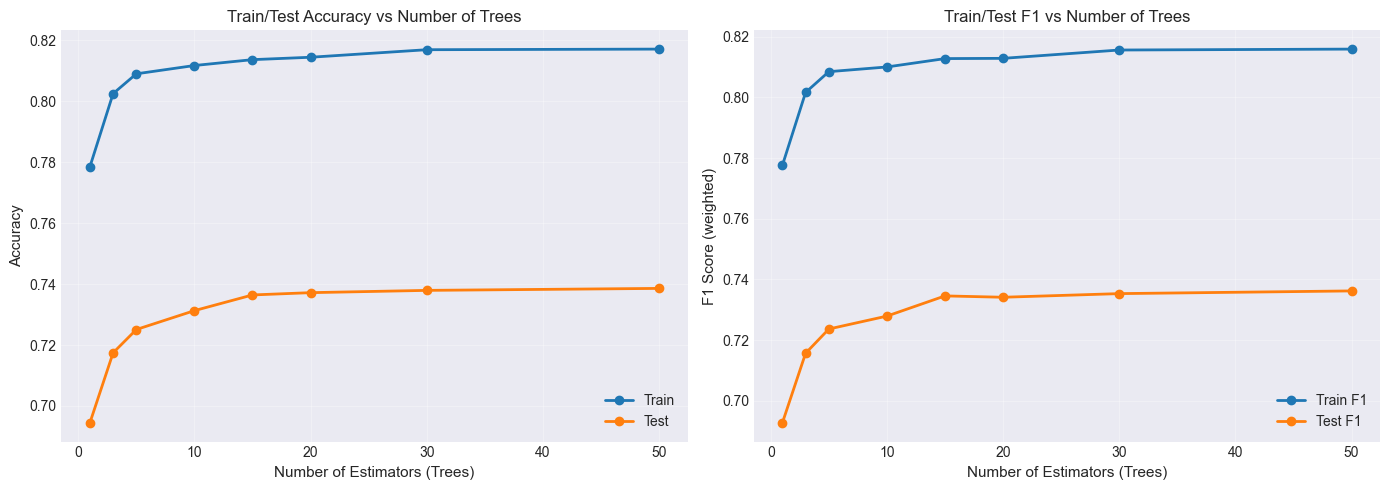

In [14]:
# Wykresy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['n_estimators'], results_df['train_accuracy'], marker='o', label='Train', linewidth=2)
axes[0].plot(results_df['n_estimators'], results_df['test_accuracy'], marker='o', label='Test', linewidth=2)
axes[0].set_xlabel('Number of Estimators (Trees)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Train/Test Accuracy vs Number of Trees', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['n_estimators'], results_df['train_f1'], marker='o', label='Train F1', linewidth=2)
axes[1].plot(results_df['n_estimators'], results_df['test_f1'], marker='o', label='Test F1', linewidth=2)
axes[1].set_xlabel('Number of Estimators (Trees)', fontsize=11)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=11)
axes[1].set_title('Train/Test F1 vs Number of Trees', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Porównanie ważności cech: Single Tree vs Bagging


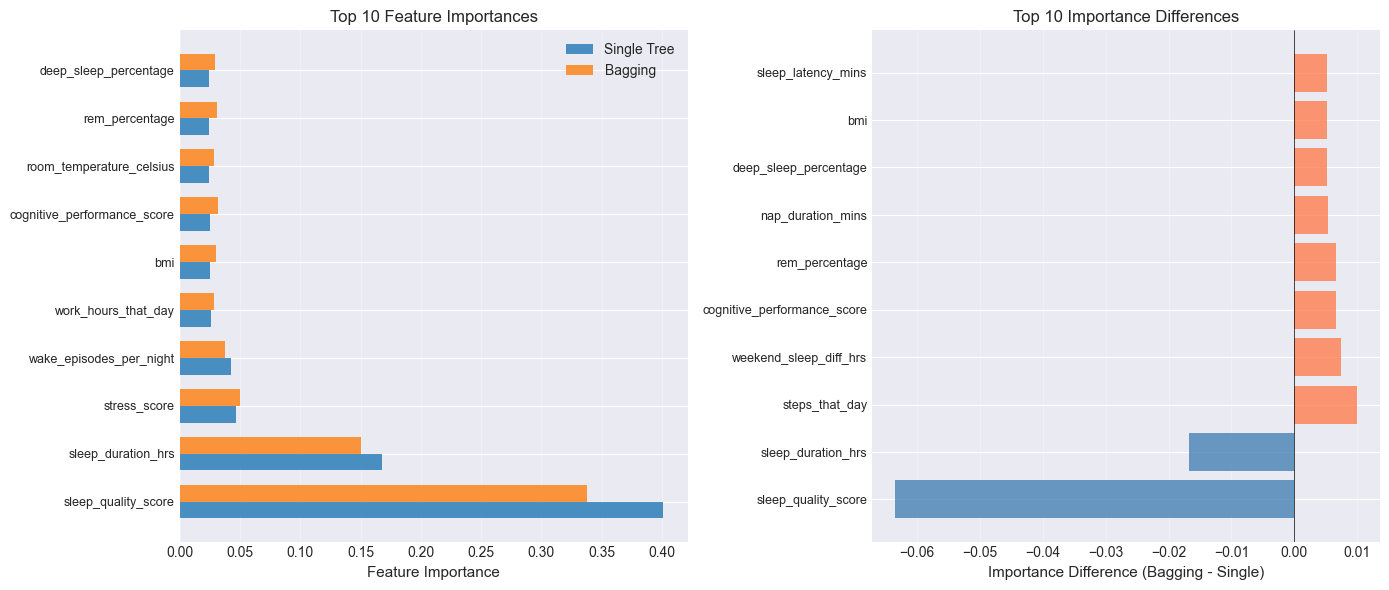


Wnioski:
• Bagging zmniejsza wariancję błędu poprzez uśrednianie predykcji z wielu modeli
• Test accuracy zwykle stopniowo się poprawia wraz ze wzrostem liczby drzew
• Custom Bagging powinien dać podobne wyniki do sklearn RandomForest (dla tego samego dataset'u)
• Ensemble methods zmniejszają przeuczenie (overfitting) zarówno dla train jak i test


In [15]:
feature_names = X_tree.columns.tolist()
fig = plot_feature_importances(single_tree, custom_bagging, feature_names, figsize=(14, 6))
plt.show()

print("\nWnioski:")
print("• Bagging zmniejsza wariancję błędu poprzez uśrednianie predykcji z wielu modeli")
print("• Test accuracy zwykle stopniowo się poprawia wraz ze wzrostem liczby drzew")
print("• Custom Bagging powinien dać podobne wyniki do sklearn RandomForest (dla tego samego dataset'u)")
print("• Ensemble methods zmniejszają przeuczenie (overfitting) zarówno dla train jak i test")

